In [1]:
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_covtype
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from torch.optim.lr_scheduler import LambdaLR

import torch._dynamo
import torch.utils.benchmark as benchmark
from torch.optim import Optimizer
from torchinfo import summary
from torch.autograd import Function

In [2]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")

In [3]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [4]:
def train(model, criterion, optimizers, epochs):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    @torch._dynamo.explain
    def run_model(x):
        return model(x)

    run_model(X_train_tensor) # type: ignore

    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    schedulers = [
        torch.optim.lr_scheduler.LinearLR(opt, start_factor=1.0, end_factor=0.05, total_iters=epochs)
        for opt in optimizers
    ]

    for epoch in range(1, epochs + 1):
        model.train()
        for opt in optimizers:
            opt.zero_grad()

        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()

        for opt in optimizers:
            opt.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        for scheduler in schedulers:
            scheduler.step()

        if epoch % 1 == 0:
            print(f"Epoch {epoch}/{epochs}, Train Loss: {train_loss.item():.32f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        print(f"[GPU] Peak memory allocated: {torch.cuda.max_memory_allocated() / 1024 ** 2:.2f} MB")
        print(f"[GPU] Peak memory reserved: {torch.cuda.max_memory_reserved() / 1024 ** 2:.2f} MB")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

In [7]:
class CReLUFunction(Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        pos = torch.relu(input)
        neg = torch.relu(-input)
        return torch.cat((pos, neg), dim=1)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors

        channels = input.shape[1]
        grad_pos = grad_output[:, :channels]
        grad_neg = grad_output[:, channels:]

        grad_input = grad_pos * (input > 0).float() - grad_neg * (input < 0).float()

        return grad_input


class CReLU(nn.Module):
    def forward(self, x):
        return CReLUFunction.apply(x)


class StableNN(nn.Module):
    def __init__(self, n, num_layers=2):
        super().__init__()
        self.first_norm = nn.BatchNorm1d(n, affine=False, track_running_stats=True)
        self.activation = CReLU()

        self.pre_norms = nn.ModuleList()
        self.linears = nn.ModuleList()
        self.post_norms = nn.ModuleList()

        for _ in range(num_layers):
            n *= 2
            self.pre_norms.append(nn.BatchNorm1d(n, affine=False, track_running_stats=True))

            self.linears.append(nn.Linear(n, 2, bias=True))
            with torch.no_grad():
                nn.init.zeros_(self.linears[-1].weight) # type: ignore
                nn.init.zeros_(self.linears[-1].bias) # type: ignore

            self.post_norms.append(nn.BatchNorm1d(1, affine=False, track_running_stats=True))
            n += 1

    def forward(self, x):
        x = self.first_norm(x)
        output = torch.zeros(x.size(0), 2)

        for prenorm, linear, postnorm in zip(self.pre_norms, self.linears, self.post_norms):
            x1 = self.activation(x)
            x2 = prenorm(x1)
            x3 = linear(x2)

            output += x3
            x = torch.cat([x2, postnorm(x3[:, 0].unsqueeze(1))], dim=1)

        return output

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                92
Total params: 92
Trainable params: 92
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0
Input size (MB): 1.21
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 1.21
_orig_mod.linears.0.weight
Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([0., 0.], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

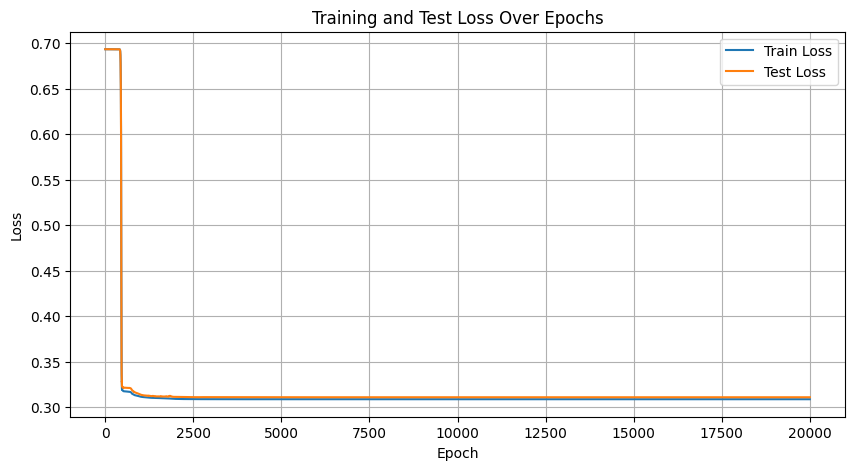

_orig_mod.linears.0.weight
Parameter containing:
tensor([[ 5.1915e-02,  4.3456e-03,  2.2338e-01,  4.7172e-04, -7.0991e-02,
          9.0710e-05,  5.1171e-03, -7.9060e-02,  1.8912e-02, -1.0959e-01,
          3.3271e-06,  2.0825e-01, -1.4334e-01, -7.2566e-03],
        [-5.1887e-02, -4.6365e-01, -4.8823e-01,  5.5623e-02, -5.5223e-04,
          3.2886e-03, -2.8316e-02,  7.8203e-02,  4.7882e-02, -1.2085e+00,
         -9.7577e-02,  2.0533e-02, -1.0284e+00, -6.9532e-03]],
       requires_grad=True)
_orig_mod.linears.0.bias
Parameter containing:
tensor([ 0.3467, -0.3434], requires_grad=True)
_orig_mod.linears.1.weight
Parameter containing:
tensor([[ 0.2930,  1.0095,  2.5491, -0.0736, -0.2499, -0.0072, -0.0288, -0.9458,
          0.3256,  0.4802,  0.3775, -0.1047,  0.3871, -0.0153, -3.0329, -0.2289,
          0.0910, -0.9661,  0.0798, -0.4180,  0.3224,  0.1951,  0.3553,  0.0171,
         -0.2262, -0.1118,  0.6358, -0.5704, -0.1211, -1.5686],
        [-0.2926, -1.0096, -2.5512,  0.0738,  0.2439,

In [10]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=2).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=20000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [11]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=3).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=20000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-11                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-12                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-13                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-11                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

KeyboardInterrupt: 

In [ ]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=20000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [12]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=5).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=20000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-19                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-20                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-21                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-19                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

KeyboardInterrupt: 

In [13]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=8).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf))
]

train(model, criterion, optimizers, epochs=20000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─StableNN: 1-1                          [43152, 2]                --
│    └─BatchNorm1d: 2-1                  [43152, 7]                --
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-31                  --                        --
│    │    └─BatchNorm1d: 3-1             [43152, 14]               --
│    └─ModuleList: 2-32                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 2]                30
│    └─ModuleList: 2-33                  --                        --
│    │    └─BatchNorm1d: 3-3             [43152, 1]                --
│    └─CReLU: 2-6                        [43152, 30]               --
│    └─ModuleList: 2-31                  --                        --
│    │    └─BatchNorm1d: 3-4             [43152, 30]               --
│    └

KeyboardInterrupt: 